In [12]:
import pandas as pd

with open("daily_data/COMMAND EVERYTHING.txt", "r") as file:
    code = file.read()
    exec(code)

df_daily_1_yr
(701568, 19)
df_daily_1_yr_no_null
(698784, 19)
df_daily_2_yr
(1397568, 19)
df_daily_2_yr_no_null
(1394784, 19)
df_daily_5_yr
(3493832, 19)
df_daily_5_yr_no_null
(3215432, 19)


This assignment asks for analysis across several different time spans.

Additionally, my metrics result in some nulls in which there are insufficient days to calculate them (such as SMA50 before the 50th day, prev_close on first day of dataset, next_close on the last day of the dataset, etc). It will be convenient in these cases to have versions with and without nulls, depending on the need (visualization/modeling etc).

Rather than storing nearly redundant version of the datasets at the cost of extra storage space, I have built a command that can be loaded from a txt file. This command:

 - Combines two datasets, one with changing daily prices, and one with unchanging metadata, which are stored separately to save space and avoid thousands of redundant items.

 - Calculates the metrics I want in the order I want (this is important as one column measures from the start of the dataset, which will change with different time spans)

 - Create multiple dataframes that can be called as necessary within the notebook depending on the requirements of the question.

Still need to improve aggregate dataset creation and add more aggregate metrics.

# 1. Fetch both daily and hourly stock market data using a suitable API. Visualize the data in several types of plots.

Refer to notebook 1A - Cleaning.

In [13]:
df_daily_5_yr

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,name,market_cap,exchange,country,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change,close_pct_of_day1
0,2021-05-24,A,133.51,134.41,132.5300,133.34,1.325305e+06,133.6936,18683.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,NaN,-0.082496,100.000000
1,2021-05-25,A,133.41,134.80,133.0100,133.23,1.905708e+06,133.6992,26967.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,-0.082496,0.045035,99.917504
2,2021-05-26,A,136.30,138.00,133.2505,133.29,2.530998e+06,134.5671,31259.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,0.045035,3.188536,99.962502
3,2021-05-27,A,133.32,138.14,133.1600,137.54,3.720923e+06,137.2590,37177.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,3.188536,0.428966,103.149843
4,2021-05-28,A,138.60,139.21,138.0001,138.13,1.289049e+06,138.4188,20108.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,0.428966,-0.673279,103.592320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493827,2026-05-15,ZYME,24.50,25.34,23.6346,23.93,6.407959e+05,23.8908,11366.0,Zymeworks Inc.,1.827577e+09,XNAS,us,25.195,26.5305,25.6757,24.81475,-0.125209,2.089427,82.975035
3493828,2026-05-18,ZYME,23.93,24.70,23.8800,24.43,7.502414e+05,24.3372,14709.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.960,26.3595,25.6827,24.78285,2.089427,-0.122800,84.708738
3493829,2026-05-19,ZYME,24.19,24.55,23.8700,24.40,6.153201e+05,24.3494,12503.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.732,26.1660,25.6857,24.75895,-0.122800,1.803279,84.604716
3493830,2026-05-20,ZYME,24.40,25.20,24.2650,24.84,5.426638e+05,24.8734,13051.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.455,25.9815,25.6733,24.73875,1.803279,1.086957,86.130374


In [ ]:

NCPC_vs_market_avg
CPD1_vs_market_avg

In [15]:
df = df_daily_5_yr

# Calculate market average for each timestamp, grouped by ticker
PCFP_market_avg = df.groupby('ticker')['pct_change_from_prev'].transform('mean')
# Find the difference
df['PCFP_vs_market_avg'] = df['pct_change_from_prev'] - PCFP_market_avg


# Calculate market average for each timestamp, grouped by ticker
NCPC_market_avg = df.groupby('ticker')['next_close_pct_change'].transform('mean')
# Find the difference
df['NCPC_vs_market_avg'] = df['next_close_pct_change'] - NCPC_market_avg


# Calculate market average for each timestamp, grouped by ticker
CPD1_market_avg = df.groupby('ticker')['close_pct_of_day1'].transform('mean')
# Find the difference
df['CPD1_vs_market_avg'] = df['close_pct_of_day1'] - CPD1_market_avg


df_daily_5_yr

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,name,...,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change,close_pct_of_day1,PCFP_vs_market_avg,NCPC_vs_market_avg,CPD1_vs_market_avg
0,2021-05-24,A,133.51,134.41,132.5300,133.34,1.325305e+06,133.6936,18683.0,Agilent Technologies Inc.,...,NaN,NaN,NaN,NaN,NaN,-0.082496,100.000000,NaN,-0.087166,-0.400916
1,2021-05-25,A,133.41,134.80,133.0100,133.23,1.905708e+06,133.6992,26967.0,Agilent Technologies Inc.,...,NaN,NaN,NaN,NaN,-0.082496,0.045035,99.917504,-0.087166,0.040365,-0.483412
2,2021-05-26,A,136.30,138.00,133.2505,133.29,2.530998e+06,134.5671,31259.0,Agilent Technologies Inc.,...,NaN,NaN,NaN,NaN,0.045035,3.188536,99.962502,0.040365,3.183867,-0.438414
3,2021-05-27,A,133.32,138.14,133.1600,137.54,3.720923e+06,137.2590,37177.0,Agilent Technologies Inc.,...,NaN,NaN,NaN,NaN,3.188536,0.428966,103.149843,3.183867,0.424296,2.748926
4,2021-05-28,A,138.60,139.21,138.0001,138.13,1.289049e+06,138.4188,20108.0,Agilent Technologies Inc.,...,NaN,NaN,NaN,NaN,0.428966,-0.673279,103.592320,0.424296,-0.677948,3.191404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493827,2026-05-15,ZYME,24.50,25.34,23.6346,23.93,6.407959e+05,23.8908,11366.0,Zymeworks Inc.,...,25.195,26.5305,25.6757,24.81475,-0.125209,2.089427,82.975035,-0.190114,2.024522,35.156185
3493828,2026-05-18,ZYME,23.93,24.70,23.8800,24.43,7.502414e+05,24.3372,14709.0,Zymeworks Inc.,...,24.960,26.3595,25.6827,24.78285,2.089427,-0.122800,84.708738,2.024522,-0.187705,36.889888
3493829,2026-05-19,ZYME,24.19,24.55,23.8700,24.40,6.153201e+05,24.3494,12503.0,Zymeworks Inc.,...,24.732,26.1660,25.6857,24.75895,-0.122800,1.803279,84.604716,-0.187705,1.738373,36.785866
3493830,2026-05-20,ZYME,24.40,25.20,24.2650,24.84,5.426638e+05,24.8734,13051.0,Zymeworks Inc.,...,24.455,25.9815,25.6733,24.73875,1.803279,1.086957,86.130374,1.738373,1.022051,38.311525


# 2. Plot long-term stock data over multiple years. Create an interactive graph that allows the user to view different time ranges.

This will be on the Streamlit app when I create it.

# 3. Start with Apple (AAPL) and plot its stock chart using daily data over several years.

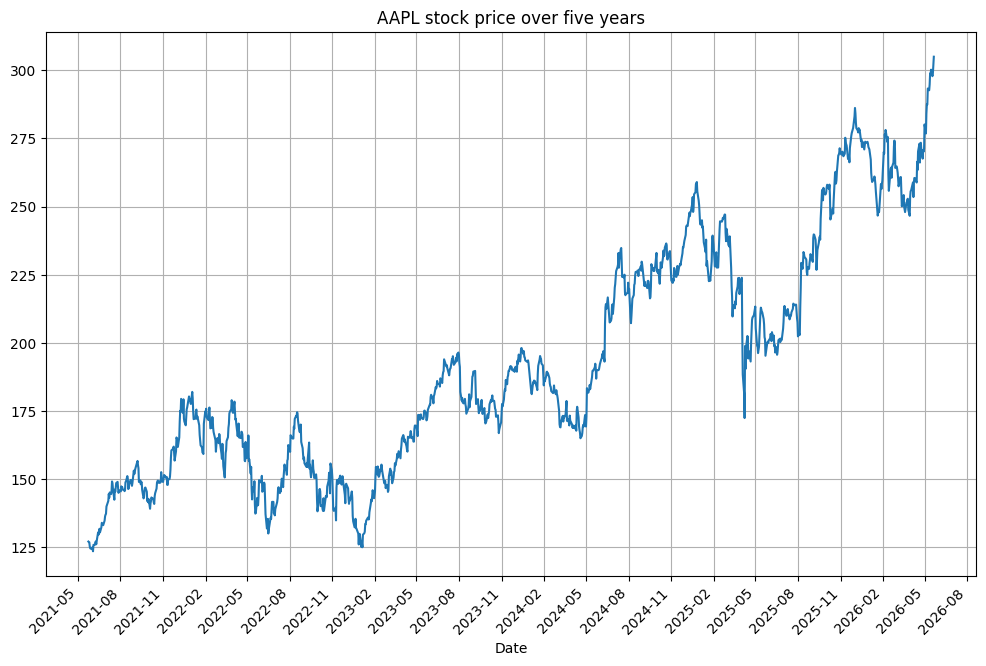

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


aapl_df = df_daily_5_yr[df_daily_5_yr['ticker'] == 'AAPL']

plt.figure(figsize=(12, 8))
aapl_df.set_index('timestamp')['close'].plot()
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.grid()
plt.title('AAPL stock price over five years')
plt.show()

# 4. Add moving averages to the stock charts.

I added SMA10, SMA20, SMA50, and SMA100. However SMA10 was excluded from the visualization as it cluttered things up and made the original line too hard to see.

In this visualization, I used the dataset which leaves the nulls from the SMAs (days for which there was insufficient data to calculate them). You can see each SMA as it begins, and see how it is still taking into account the days before it. 

The more days in the SMA, the smoother the line gets.

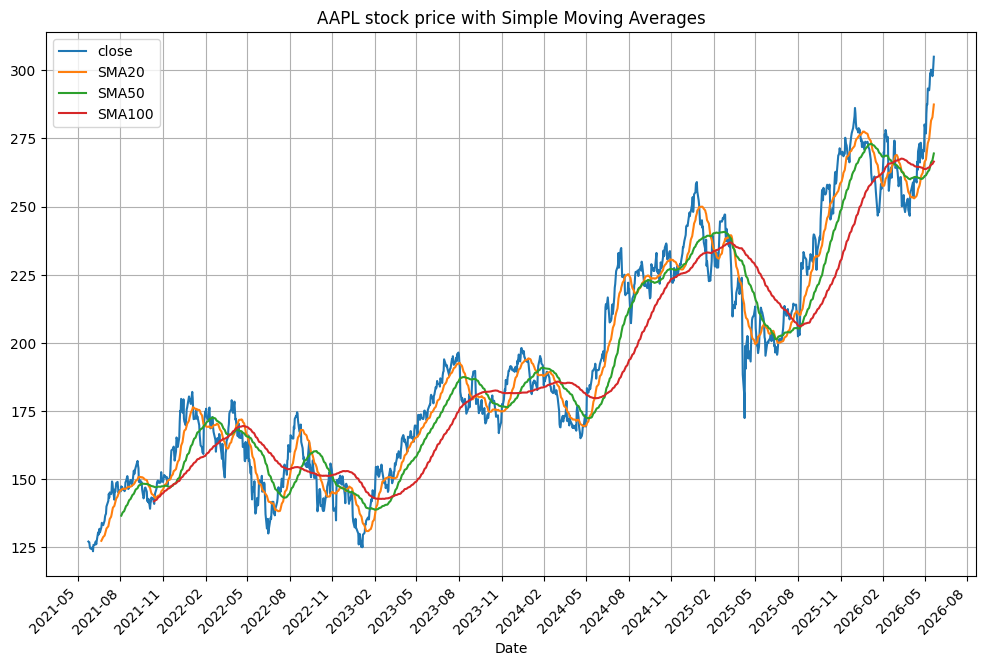

In [10]:
import matplotlib.pyplot as plt

aapl_df = df_daily_5_yr[df_daily_5_yr['ticker'] == 'AAPL']

features_to_plot = ['close', 'SMA20', 'SMA50', 'SMA100']

plt.figure(figsize=(12, 8))

for feature in features_to_plot:
    aapl_df.set_index('timestamp')[feature].plot()
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.title('AAPL stock price with Simple Moving Averages')
    plt.legend()
plt.grid()
plt.show()

# 5. Create a table for five stocks. Use default examples such as FAANG stocks plus NVIDIA, but allow the user to change them.

For each stock, calculate the historical probability that the next day is positive if the
current day changes by: +2%, +3%, +4%, +5%, and +6%.

Example: if Apple rises 5% today, what is the historical probability that the next day closes positive?

Use the last 2 years of historical data.


Here I will use seven standard tech stocks. In the eventual streamlit page, I will introduce the interactivity.

I was asked to verify my calculations, so I did a small version here. I am confident that my calculations are correct.

In [11]:
aapl_two_yr = df_daily_2_yr[df_daily_2_yr['ticker'] == 'AAPL']

increase_2pct = (aapl_two_yr['pct_change_from_prev'] >= 2).sum()
increase_2pct_and_next_pos = ((aapl_two_yr['pct_change_from_prev'] >= 2) & (aapl_two_yr['next_close_pct_change'] >= 0)).sum()
increase_2pct_and_next_neg = ((aapl_two_yr['pct_change_from_prev'] >= 2) & (aapl_two_yr['next_close_pct_change'] < 0)).sum()


print(f"Days with 2% increase over previous day:\n\t{increase_2pct}")
print(f"Days with 2% increase over previous day AND next day positive:\n\t{increase_2pct_and_next_pos}")
print(f"Days with 2% increase over previous day AND next day negative:\n\t{increase_2pct_and_next_neg}")
print(f"Percentage of 2% increase days where next day was positive:\n\t" f"{(increase_2pct_and_next_pos / increase_2pct) * 100:.3f}%")

Days with 2% increase over previous day:
	43
Days with 2% increase over previous day AND next day positive:
	29
Days with 2% increase over previous day AND next day negative:
	14
Percentage of 2% increase days where next day was positive:
	67.442%


For visual verification, I'll run boolean indexing on rows satisying conditions.

In [12]:
(aapl_two_yr['pct_change_from_prev'] >= 2).sum()

np.int64(43)

In [13]:
((aapl_two_yr['pct_change_from_prev'] >= 2) & (aapl_two_yr['next_close_pct_change'] >= 0)).sum()

np.int64(29)

In [14]:
#ticker_list = df_daily_two_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META', 'MSFT']

thresholds = 2, 3, 4, 5, 6, 10, 20

master_df = df_daily_2_yr

print("Span: 2 years\n")

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] >= 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}:\tProbability of a positive change the day after a {threshold}% increase:\t{full_condition_pct:.3f}\t({matching_days} / {total_prev_days})")
        else:
            print(f"{ticker}:\t>>>> No days with a {threshold}% increase <<<<")

    print(f"-------------------------------------------------------------------------------------------")

Span: 2 years

AAPL:	Probability of a positive change the day after a 2% increase:	67.442	(29 / 43)
AAPL:	Probability of a positive change the day after a 3% increase:	66.667	(12 / 18)
AAPL:	Probability of a positive change the day after a 4% increase:	50.000	(4 / 8)
AAPL:	Probability of a positive change the day after a 5% increase:	75.000	(3 / 4)
AAPL:	Probability of a positive change the day after a 6% increase:	66.667	(2 / 3)
AAPL:	Probability of a positive change the day after a 10% increase:	0.000	(0 / 1)
AAPL:	>>>> No days with a 20% increase <<<<
-------------------------------------------------------------------------------------------
NVDA:	Probability of a positive change the day after a 2% increase:	53.846	(63 / 117)
NVDA:	Probability of a positive change the day after a 3% increase:	50.667	(38 / 75)
NVDA:	Probability of a positive change the day after a 4% increase:	52.500	(21 / 40)
NVDA:	Probability of a positive change the day after a 5% increase:	57.895	(11 / 19)
NVDA:	

# 6. Repeat the same analysis for negative daily moves, such as: -2%, -3%, -4%, and -5%.

In [15]:
#ticker_list = df_daily_two_years['ticker'].unique().tolist()
ticker_list = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

thresholds = -1, -2, -3, -4, -5, -6, -10, -15, -20

master_df = df_daily_2_yr

print("Span: 2 years\n")

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] <= threshold
        next_change_condition = ticker_df['next_close_pct_change'] < 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}:\tProbability of a negative change the day after a {threshold}% decrease:\t{full_condition_pct:.3f}\t({matching_days} / {total_prev_days})")

        else:
            print(f"{ticker}:\t>>>> No days with a {threshold}% decrease <<<<")
    print(f"-------------------------------------------------------------------------------------------")

Span: 2 years

AMZN:	Probability of a negative change the day after a -1% decrease:	45.312	(58 / 128)
AMZN:	Probability of a negative change the day after a -2% decrease:	40.741	(22 / 54)
AMZN:	Probability of a negative change the day after a -3% decrease:	44.000	(11 / 25)
AMZN:	Probability of a negative change the day after a -4% decrease:	50.000	(7 / 14)
AMZN:	Probability of a negative change the day after a -5% decrease:	80.000	(4 / 5)
AMZN:	Probability of a negative change the day after a -6% decrease:	100.000	(3 / 3)
AMZN:	>>>> No days with a -10% decrease <<<<
AMZN:	>>>> No days with a -15% decrease <<<<
AMZN:	>>>> No days with a -20% decrease <<<<
-------------------------------------------------------------------------------------------
AAPL:	Probability of a negative change the day after a -1% decrease:	44.681	(42 / 94)
AAPL:	Probability of a negative change the day after a -2% decrease:	40.909	(18 / 44)
AAPL:	Probability of a negative change the day after a -3% decrease:	40.0

# 7a. Positive moves over 5 years

In [16]:
#ticker_list = df_daily_two_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META', 'MSFT']

thresholds = 2, 3, 4, 5, 6, 10, 20

master_df = df_daily_5_yr

print("Span: 5 years\n")

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] >= 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}:\tProbability of a positive change the day after a {threshold}% increase:\t{full_condition_pct:.3f}\t({matching_days} / {total_prev_days})")
        else:
            print(f"{ticker}:\t>>>> No days with a {threshold}% increase <<<<")

    print(f"-------------------------------------------------------------------------------------------")

Span: 5 years

AAPL:	Probability of a positive change the day after a 2% increase:	53.226	(66 / 124)
AAPL:	Probability of a positive change the day after a 3% increase:	50.000	(23 / 46)
AAPL:	Probability of a positive change the day after a 4% increase:	42.105	(8 / 19)
AAPL:	Probability of a positive change the day after a 5% increase:	62.500	(5 / 8)
AAPL:	Probability of a positive change the day after a 6% increase:	66.667	(4 / 6)
AAPL:	Probability of a positive change the day after a 10% increase:	0.000	(0 / 1)
AAPL:	>>>> No days with a 20% increase <<<<
-------------------------------------------------------------------------------------------
NVDA:	Probability of a positive change the day after a 2% increase:	54.921	(173 / 315)
NVDA:	Probability of a positive change the day after a 3% increase:	54.187	(110 / 203)
NVDA:	Probability of a positive change the day after a 4% increase:	53.175	(67 / 126)
NVDA:	Probability of a positive change the day after a 5% increase:	56.944	(41 / 72)


# 7b. Negative moves over 5 years

In [17]:
#ticker_list = df_daily_two_years['ticker'].unique().tolist()
ticker_list = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

thresholds = -1, -2, -3, -4, -5, -6, -10, -15, -20

master_df = df_daily_5_yr

print("Span: 5 years\n")

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] <= threshold
        next_change_condition = ticker_df['next_close_pct_change'] < 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}:\tProbability of a negative change the day after a {threshold}% decrease:\t{full_condition_pct:.3f}\t({matching_days} / {total_prev_days})")
        else:
            print(f"{ticker}:\t>>>> No days with a {threshold}% decrease <<<<")
    print(f"-------------------------------------------------------------------------------------------")

Span: 5 years

AMZN:	Probability of a negative change the day after a -1% decrease:	47.661	(163 / 342)
AMZN:	Probability of a negative change the day after a -2% decrease:	44.025	(70 / 159)
AMZN:	Probability of a negative change the day after a -3% decrease:	44.872	(35 / 78)
AMZN:	Probability of a negative change the day after a -4% decrease:	53.488	(23 / 43)
AMZN:	Probability of a negative change the day after a -5% decrease:	52.174	(12 / 23)
AMZN:	Probability of a negative change the day after a -6% decrease:	54.545	(6 / 11)
AMZN:	Probability of a negative change the day after a -10% decrease:	0.000	(0 / 1)
AMZN:	>>>> No days with a -15% decrease <<<<
AMZN:	>>>> No days with a -20% decrease <<<<
-------------------------------------------------------------------------------------------
AAPL:	Probability of a negative change the day after a -1% decrease:	51.181	(130 / 254)
AAPL:	Probability of a negative change the day after a -2% decrease:	43.860	(50 / 114)
AAPL:	Probability of a neg

# 8. Create a comparison table for the five selected stocks. Include a simple correlation / collinearity analysis between them.

I calculated several aggregate metrics.

"wheel spinner score" is something I made up. It divides the average absolute daily percentage change, by the change from the beginning to the end of the dataset. A higher score is meant to punish stocks that are erratic without producing long-term gains. I may adjust the calculation to weight erraticism higher.

Still working on exactly which and how many metrics to feature here, but from my limited work so far, it is clear that the seven tech stocks I chose are colinear to a far greater extent than the dataset as a whole.

These will be used for question 8, and also for further analysis at the end later.

In [82]:
# Calculate aggregates from the entire dataset

df_daily_five_yr_agg = df_daily_5_yr.copy()

df_daily_five_yr_agg = df_daily_5_yr.sort_values(['ticker', 'timestamp']).copy()

df_daily_five_yr_agg['avg_daily_return'] = df_daily_five_yr_agg.groupby('ticker')['pct_change_from_prev'].transform('mean')

df_daily_five_yr_agg['avg_volume'] = df_daily_five_yr_agg.groupby('ticker')['volume'].transform('mean')

df_daily_five_yr_agg['avg_abs_daily_pct_change'] = (
    df_daily_five_yr_agg['pct_change_from_prev']
    .abs()
    .groupby(df_daily_five_yr_agg['ticker'])
    .transform('mean')
)

df_daily_five_yr_agg['change_begin_to_end'] = (
    df_daily_five_yr_agg.groupby('ticker')['close']
    .transform(lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100)
)

# df_daily_five_yr_agg['CBTE_vs_market_avg'] = df_daily_five_yr_agg['change_begin_to_end'] - ((df_daily_five_yr_agg['change_begin_to_end']).mean())




market_avg_cbte = (
    df_daily_five_yr_agg[['ticker', 'change_begin_to_end']]
    .drop_duplicates()
    ['change_begin_to_end']
    .mean()
)

df_daily_five_yr_agg['CBTE_vs_market_avg'] = (
    df_daily_five_yr_agg['change_begin_to_end'] - market_avg_cbte
)





df_daily_five_yr_agg['std_dev_daily_return'] = df_daily_five_yr_agg.groupby('ticker')['pct_change_from_prev'].transform('std')





# df_daily_five_yr_agg['wheel_spinner_score'] = df_daily_five_yr_agg['avg_abs_daily_pct_change'] / df_daily_five_yr_agg['change_begin_to_end']



# df_daily_five_yr_agg['wheel_spinner_score'] = (
#     df_daily_five_yr_agg['avg_abs_daily_pct_change'] 
#     / df_daily_five_yr_agg['change_begin_to_end'].abs()
# )


df_daily_five_yr_agg['pct_days_positive'] = (
    df_daily_five_yr_agg.groupby('ticker')['pct_change_from_prev']
    .transform(lambda x: (x > 0).mean() * 100)
)


df_daily_five_yr_agg['wheel_spinner_score'] = df_daily_five_yr_agg['avg_abs_daily_pct_change'] / (abs(df_daily_five_yr_agg['change_begin_to_end']) ** 1.5) 


df_daily_five_yr_agg['daily_return_vs_market_avg'] = df_daily_five_yr_agg.groupby('ticker')['NCPC_vs_market_avg'].transform('mean')





df_daily_five_yr_agg = (
    df_daily_five_yr_agg[
        [
            'ticker',
            'name',
            'avg_daily_return',
            'avg_volume',
            'avg_abs_daily_pct_change',
            'change_begin_to_end',
            'CBTE_vs_market_avg',
            'daily_return_vs_market_avg',
            'std_dev_daily_return',
            'wheel_spinner_score',
            'pct_days_positive'
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

df_daily_five_yr_agg

,ticker,name,avg_daily_return,avg_volume,avg_abs_daily_pct_change,change_begin_to_end,CBTE_vs_market_avg,daily_return_vs_market_avg,std_dev_daily_return,wheel_spinner_score,pct_days_positive
0,A,Agilent Technologies Inc.,0.004670,1.805358e+06,1.345186,-13.911804,-50.077913,5.621943e-17,1.824594,0.025924,50.756972
1,AA,Alcoa Corporation,0.109279,6.335206e+06,2.684390,81.561644,45.395535,2.903933e-17,3.517789,0.003644,49.641434
2,AAL,American Airlines Group Inc.,0.003492,4.011288e+07,2.163889,-40.887342,-77.053451,3.683037e-17,3.024107,0.008277,48.764940
3,AAOI,"Applied Optoelectronics, Inc.",0.510950,2.845072e+06,4.937810,2152.356688,2116.190579,-5.737038e-17,7.455645,0.000049,47.888446
4,AAON,Aaon Inc,0.127933,5.745920e+05,1.891578,199.254069,163.087960,1.770691e-18,2.859055,0.000673,52.350598
...,...,...,...,...,...,...,...,...,...,...,...
2779,ZNTL,"Zentalis Pharmaceuticals, Inc. Common Stock",-0.032984,9.350650e+05,3.826799,-92.755906,-128.922014,-2.833105e-18,5.959220,0.004284,47.250996
2780,ZS,"Zscaler, Inc. Common Stock",0.056485,2.257284e+06,2.362731,-1.943807,-38.109916,4.603796e-17,3.401382,0.871835,53.227092
2781,ZTS,ZOETIS INC.,-0.046195,2.615415e+06,1.246394,-54.608844,-90.774952,6.551555e-18,1.808121,0.003089,49.561753
2782,ZUMZ,Zumiez Inc.,0.004638,3.072232e+05,2.391549,-44.188258,-80.354366,-1.204070e-17,3.204282,0.008142,47.968127


In [74]:
df_daily_five_yr_agg.columns

Index(['ticker', 'name', 'avg_daily_return', 'avg_volume',
       'avg_abs_daily_pct_change', 'change_begin_to_end', 'CBTE_vs_market_avg',
       'daily_return_vs_market_avg', 'std_dev_daily_return',
       'wheel_spinner_score'],
      dtype='object')

In [94]:
import pandas as pd

# Get numeric columns only
numeric_cols = df_daily_five_yr_agg.select_dtypes(include='number').columns

for col in numeric_cols:
    
    # Index of max value
    idx = df_daily_five_yr_agg[col].idxmax()
    
    # Pull row
    row = df_daily_five_yr_agg.loc[idx]
    
    print(f"{col}")
    print(f"  Ticker: {row['ticker']}")
    print(f"  Name:   {row['name']}")
    print(f"  Value:  {row[col]:,.4f}")
    print()

avg_daily_return
  Ticker: MTC
  Name:   MMTec, Inc. Common Shares
  Value:  0.8393

avg_volume
  Ticker: NVDA
  Name:   Nvidia Corp
  Value:  382,663,793.0778

avg_abs_daily_pct_change
  Ticker: ADTX
  Name:   Aditxt, Inc. Common Stock
  Value:  7.0347

change_begin_to_end
  Ticker: AEHR
  Name:   Aehr Test Systems
  Value:  4,166.3551

CBTE_vs_market_avg
  Ticker: AEHR
  Name:   Aehr Test Systems
  Value:  4,130.1890

daily_return_vs_market_avg
  Ticker: TNXP
  Name:   Tonix Pharmaceuticals Holding Corp.
  Value:  0.0000

std_dev_daily_return
  Ticker: VVOS
  Name:   Vivos Therapeutics, Inc. Common Stock
  Value:  25.1908

wheel_spinner_score
  Ticker: FMBH
  Name:   First Mid Bancshares, Inc. Common Stock
  Value:  131.3910

pct_days_positive
  Ticker: EPD
  Name:   Enterprise Products Partners L.P.
  Value:  55.4582



In [81]:
df_daily_five_yr_agg.nlargest(10, 'wheel_spinner_score')

,ticker,name,avg_daily_return,avg_volume,avg_abs_daily_pct_change,change_begin_to_end,CBTE_vs_market_avg,daily_return_vs_market_avg,std_dev_daily_return,wheel_spinner_score,pct_days_positive
980,FMBH,"First Mid Bancshares, Inc. Common Stock",0.014509,5.572934e+04,1.282912,-0.045683,-36.211792,2.337312e-17,1.710399,2.818730,46.613546
1167,HBNC,"Horizon Bancorp, Inc. Common Stock",0.025681,2.015998e+05,1.581797,-0.054259,-36.220368,-2.757851e-17,2.263122,2.579082,48.525896
1344,IVZ,Invesco LTD,0.026581,4.725627e+06,1.689309,-0.074074,-36.240183,5.154646e-17,2.314591,1.640572,51.075697
1666,MSBI,"Midland States Bancorp, Inc. Common Stock",0.021335,9.370011e+04,1.463648,-0.072464,-36.238573,-1.602475e-17,2.059985,1.536167,48.844622
2468,TNL,Travel + Leisure Co.,0.027165,6.981839e+05,1.688307,-0.122418,-36.288527,4.338192e-18,2.333899,0.779031,50.597610
2143,RLI,RLI Corp.,0.010628,4.216201e+05,1.097538,-0.094233,-36.260342,-7.082763e-18,1.464134,0.738243,51.394422
1332,IRT,Independence Realty Trust Inc.,0.014668,2.289890e+06,1.273556,0.178998,-35.987111,-6.082322e-17,1.704528,0.331844,50.677291
1297,INDB,Independent Bank Corp/MA,0.019875,2.658809e+05,1.455574,-0.240964,-36.407073,4.174403e-17,2.011435,0.259122,47.490040
2741,WVE,Wave Life Sciences Ltd. Ordinary Shares,0.212716,1.335692e+06,3.880735,-0.619195,-36.785304,6.374486e-17,7.216147,0.166319,47.888446
734,DBX,"Dropbox, Inc. Class A",0.022556,3.553855e+06,1.437447,0.368324,-35.797785,-4.426727e-18,2.086580,0.123778,51.952191


In [95]:
# Reduce the aggregates to seven tech stocks
tech_stocks = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']
tech_stock_agg = df_daily_five_yr_agg[df_daily_five_yr_agg['ticker'].isin(tech_stocks)]
tech_stock_agg

,ticker,name,avg_daily_return,avg_volume,avg_abs_daily_pct_change,change_begin_to_end,CBTE_vs_market_avg,daily_return_vs_market_avg,std_dev_daily_return,wheel_spinner_score,pct_days_positive
6,AAPL,Apple Inc.,0.084666,6.546457e+07,1.223964,139.960661,103.794552,2.806545e-17,1.727657,0.000739,53.147410
157,AMZN,Amazon.Com Inc,0.065047,5.558522e+07,1.595278,65.461219,29.295110,2.992467e-17,2.232519,0.003012,51.553785
1114,GOOGL,Alphabet Inc. Class A Common Stock,0.114158,3.202828e+07,1.429621,228.380714,192.214605,3.930933e-17,1.967593,0.000414,53.306773
1600,META,"Meta Platforms, Inc. Class A Common Stock",0.088578,2.139402e+07,1.779179,87.099159,50.933050,-2.293044e-17,2.764170,0.002189,51.633466
1669,MSFT,Microsoft Corp,0.054747,2.600132e+07,1.195308,67.114602,30.948494,-5.648503e-17,1.661251,0.002174,51.553785
1736,NFLX,NetFlix Inc,0.084197,5.748066e+07,1.745100,77.570093,41.403985,-5.666210e-18,2.714601,0.002554,50.916335
1799,NVDA,Nvidia Corp,0.263340,3.826638e+08,2.391630,1306.033820,1269.867711,2.691450e-17,3.253702,0.000051,53.784861


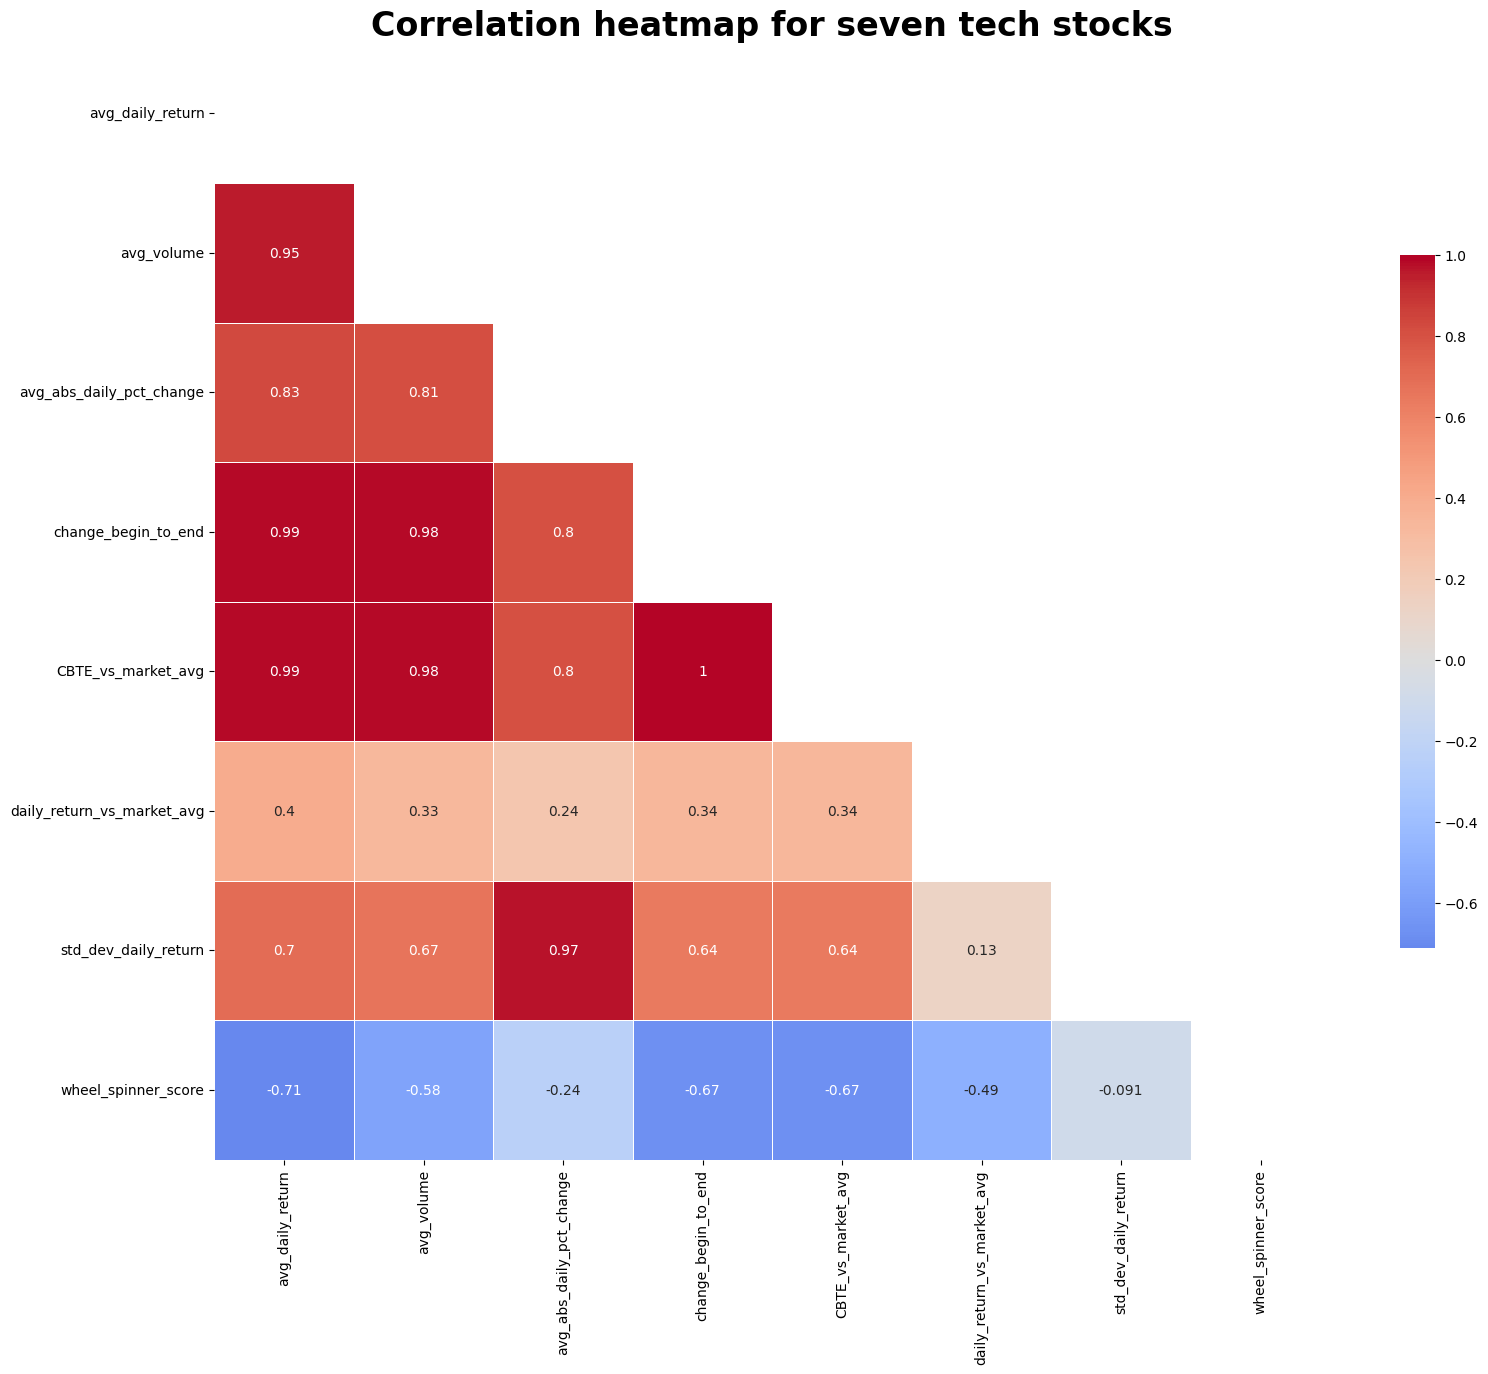

In [89]:
import numpy as np
import seaborn as sns

#sns.set(style="whitegrid")

# Generate a mask for the upper triangle
mask = np.zeros_like(tech_stock_agg.corr(numeric_only = True), dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(18, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(tech_stock_agg.corr(numeric_only = True), mask=mask, cmap='coolwarm', vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

plt.title("Correlation heatmap for seven tech stocks", fontsize=24, fontweight='bold')

#plt.savefig("name.png")
#plt.title(r"\Huge{Main Title} \large{Sub-header}")
plt.show()

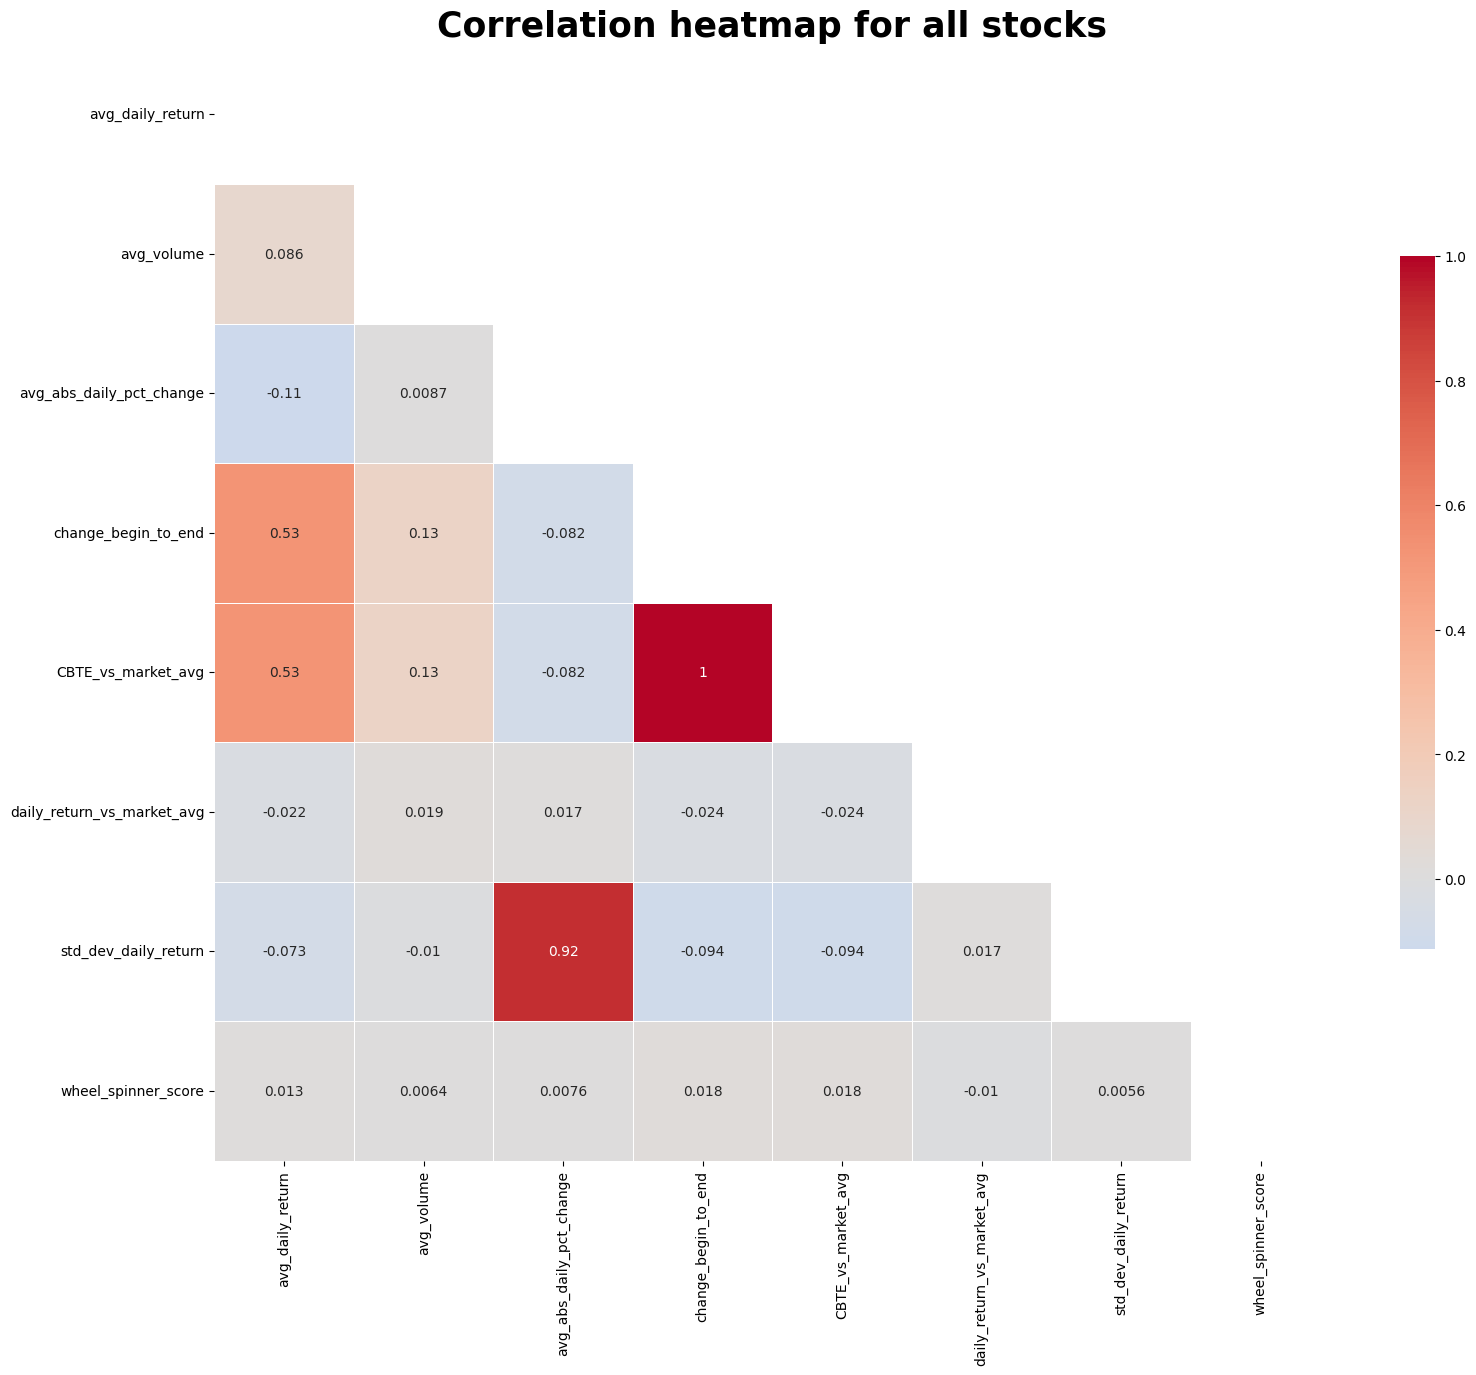

In [33]:
import numpy as np
import seaborn as sns

#sns.set(style="whitegrid")

# Generate a mask for the upper triangle
mask = np.zeros_like(df_daily_five_yr_agg.corr(numeric_only = True), dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(18, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(df_daily_five_yr_agg.corr(numeric_only = True), mask=mask, cmap='coolwarm', vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

plt.title("Correlation heatmap for all stocks", fontsize=25, fontweight='bold')
#plt.savefig("name.png")
plt.show()

# 9. Plot a comparison chart for two to five stocks using daily data for one year.


Wrote the for loop myself. Sought a bit of help to make formatting work (was mistakenly putting figsize inside the for loop which made it not work).

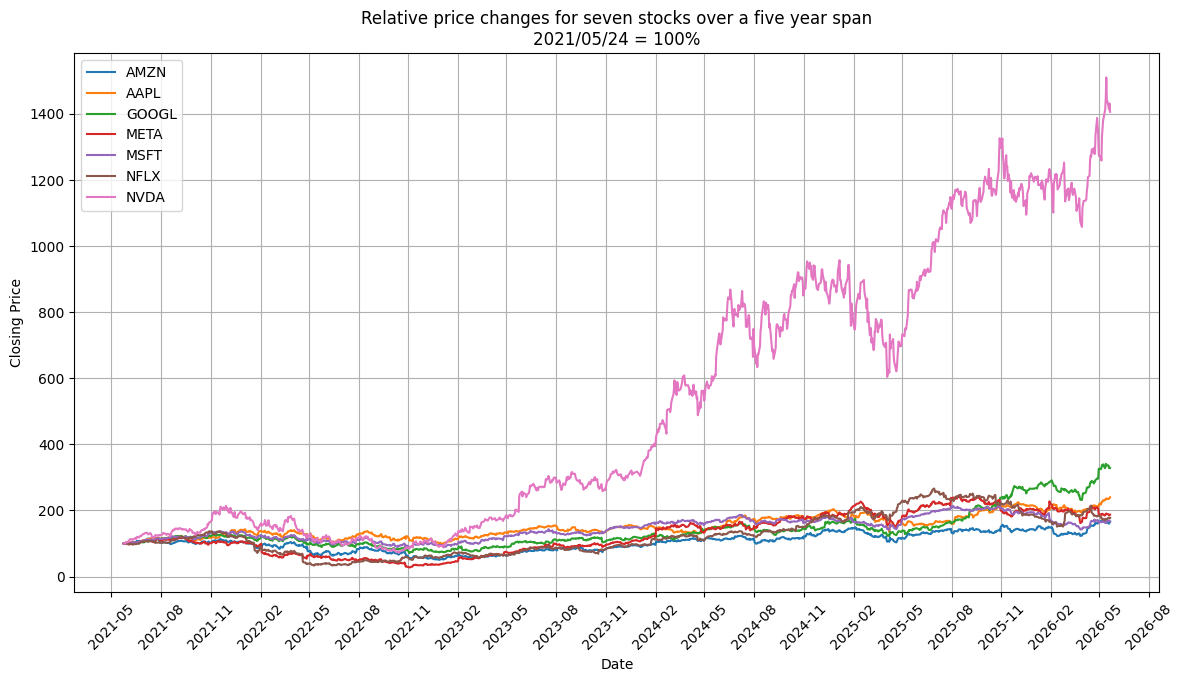

In [22]:
# Five year span
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tech_stocks = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

master_df = df_daily_5_yr

plt.figure(figsize=(14, 7))

for stock in tech_stocks:
    stock_df = master_df[master_df['ticker'] == stock]
    plt.plot(stock_df['timestamp'], stock_df['close_pct_of_day1'], label=stock)
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.title(
    f'Relative price changes for seven stocks over a five year span\n'
    f'{(master_df['timestamp'].min()):%Y/%m/%d} = 100%')
    plt.legend()

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.grid()
plt.show()

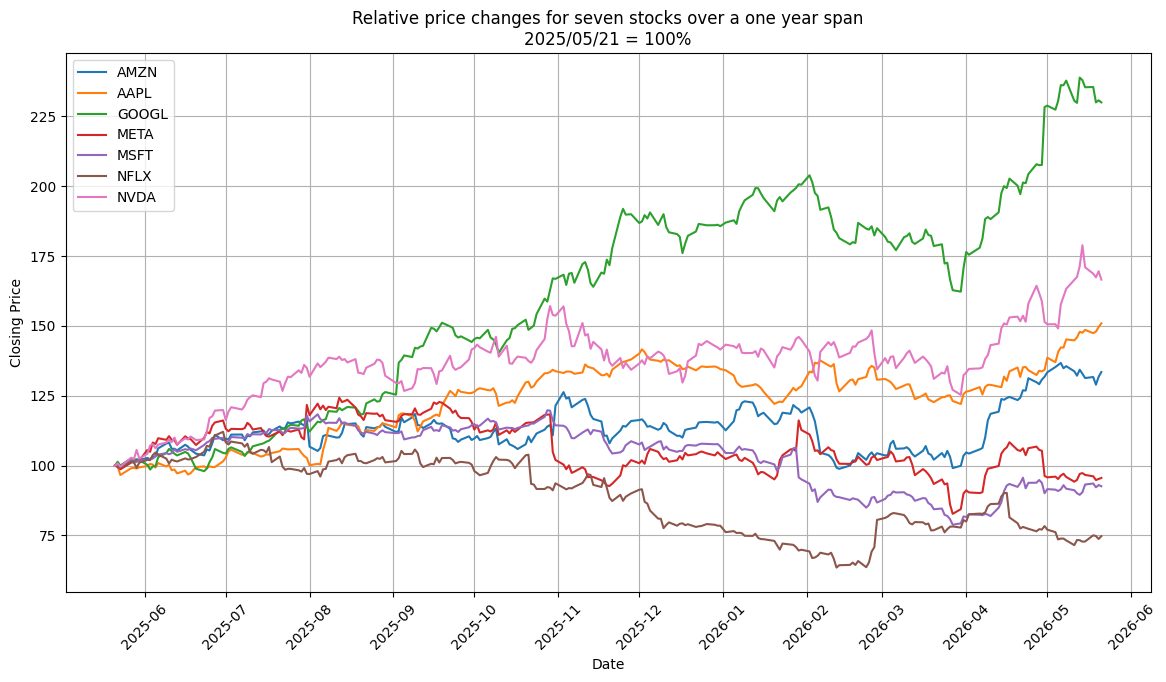

In [23]:
# One year span
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tech_stocks = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

#master_df = df_daily_five_yr
#master_df = df_daily_two_yr
master_df = df_daily_1_yr

earliest_date = master_df['timestamp'].min()

plt.figure(figsize=(14, 7))

for stock in tech_stocks:
    stock_df = master_df[master_df['ticker'] == stock]
    plt.plot(stock_df['timestamp'], stock_df['close_pct_of_day1'], label=stock)
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.title(
    f'Relative price changes for seven stocks over a one year span\n'
    f'{earliest_date:%Y/%m/%d} = 100%')
    plt.legend()

# Fewer x-axis ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Optional rotation
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 10. Create another table for the same five stocks showing the probability that the next day is positive after:
● 2 consecutive positive days
● 3 consecutive positive days
● 4 consecutive positive days
● 5 consecutive positive days
● 6 consecutive positive days

Here, I created columns counting consecutive days of either positive or negative growth. Each day resets to 0 when the streak ends.

Further below, I largely copied percentage growth code, filtering 

In [25]:
super_safe_df = df_daily_5_yr.copy()

pos_mask = super_safe_df['pct_change_from_prev'] >= 0
streak_id = (pos_mask != pos_mask.shift()).cumsum()
super_safe_df['positive_day_streak'] = super_safe_df.groupby(streak_id).cumcount() + 1
super_safe_df.loc[~pos_mask, 'positive_day_streak'] = 0

neg_mask = super_safe_df['pct_change_from_prev'] < 0
streak_id = (neg_mask != neg_mask.shift()).cumsum()
super_safe_df['negative_day_streak'] = super_safe_df.groupby(streak_id).cumcount() + 1
super_safe_df.loc[~neg_mask, 'negative_day_streak'] = 0

super_safe_df.head(10)

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,name,...,country,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change,close_pct_of_day1,positive_day_streak,negative_day_streak
0,2021-05-24,A,133.51,134.410,132.5300,133.34,1325305.0,133.6936,18683.0,Agilent Technologies Inc.,...,us,NaN,NaN,NaN,NaN,NaN,-0.082496,100.000000,0,0
1,2021-05-25,A,133.41,134.800,133.0100,133.23,1905708.0,133.6992,26967.0,Agilent Technologies Inc.,...,us,NaN,NaN,NaN,NaN,-0.082496,0.045035,99.917504,0,1
2,2021-05-26,A,136.30,138.000,133.2505,133.29,2530998.0,134.5671,31259.0,Agilent Technologies Inc.,...,us,NaN,NaN,NaN,NaN,0.045035,3.188536,99.962502,1,0
3,2021-05-27,A,133.32,138.140,133.1600,137.54,3720923.0,137.2590,37177.0,Agilent Technologies Inc.,...,us,NaN,NaN,NaN,NaN,3.188536,0.428966,103.149843,2,0
4,2021-05-28,A,138.60,139.210,138.0001,138.13,1289049.0,138.4188,20108.0,Agilent Technologies Inc.,...,us,NaN,NaN,NaN,NaN,0.428966,-0.673279,103.592320,3,0
5,2021-06-01,A,139.17,140.320,135.5700,137.20,2056317.0,137.2481,26916.0,Agilent Technologies Inc.,...,us,NaN,NaN,NaN,NaN,-0.673279,-0.459184,102.894855,0,1
6,2021-06-02,A,137.12,138.220,135.8800,136.57,1409862.0,136.8016,21030.0,Agilent Technologies Inc.,...,us,NaN,NaN,NaN,NaN,-0.459184,-0.146445,102.422379,0,2
7,2021-06-03,A,136.00,136.910,135.7400,136.37,1244583.0,136.4143,19217.0,Agilent Technologies Inc.,...,us,NaN,NaN,NaN,NaN,-0.146445,1.121948,102.272386,0,3
8,2021-06-04,A,137.70,138.409,137.3850,137.90,1085063.0,137.9736,19293.0,Agilent Technologies Inc.,...,us,NaN,NaN,NaN,NaN,1.121948,-0.181291,103.419829,1,0
9,2021-06-07,A,138.09,138.580,137.3701,137.65,951666.0,137.8752,17731.0,Agilent Technologies Inc.,...,us,136.122,NaN,NaN,NaN,-0.181291,0.799128,103.232338,0,1


In [26]:
ticker_list = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

thresholds = 2, 3, 4, 5, 6, 10, 20

master_df = super_safe_df

print("Span: 5 years\n")

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        consec_days_condition = ticker_df['positive_day_streak'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] >= 0


        full_condition = consec_days_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = consec_days_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}:\tProbability of a positive change after at least {threshold} consecutive positive days:\t{full_condition_pct:.3f}\t({matching_days} / {total_prev_days})")
        else:
            print(f"{ticker}:\t>>>> No days with a {threshold}% decrease <<<<")
    print(f"-----------------------------------------------------------------------------------------------------------")

Span: 5 years

AMZN:	Probability of a positive change after at least 2 consecutive positive days:	53.235	(181 / 340)
AMZN:	Probability of a positive change after at least 3 consecutive positive days:	51.381	(93 / 181)
AMZN:	Probability of a positive change after at least 4 consecutive positive days:	46.237	(43 / 93)
AMZN:	Probability of a positive change after at least 5 consecutive positive days:	39.535	(17 / 43)
AMZN:	Probability of a positive change after at least 6 consecutive positive days:	35.294	(6 / 17)
AMZN:	>>>> No days with a 10% decrease <<<<
AMZN:	>>>> No days with a 20% decrease <<<<
-----------------------------------------------------------------------------------------------------------
AAPL:	Probability of a positive change after at least 2 consecutive positive days:	52.186	(191 / 366)
AAPL:	Probability of a positive change after at least 3 consecutive positive days:	50.262	(96 / 191)
AAPL:	Probability of a positive change after at least 4 consecutive positive days:	5

# 11. Repeat the same analysis for consecutive negative days.

In [27]:
ticker_list = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

thresholds = 2, 3, 4, 5, 6, 10

master_df = super_safe_df

print("Span: 5 years\n")

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        consec_days_condition = ticker_df['negative_day_streak'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] < 0


        full_condition = consec_days_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = consec_days_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}:\tProbability of a negative change after {threshold} consecutive negative days:\t{full_condition_pct:.3f}\t({matching_days} / {total_prev_days})")
        else:
            print(f"{ticker}:\t>>>> No days with a {threshold}% decrease <<<<")
    print(f"-----------------------------------------------------------------------------------------------------------")

Span: 5 years

AMZN:	Probability of a negative change after 2 consecutive negative days:	48.475	(143 / 295)
AMZN:	Probability of a negative change after 3 consecutive negative days:	46.154	(66 / 143)
AMZN:	Probability of a negative change after 4 consecutive negative days:	48.485	(32 / 66)
AMZN:	Probability of a negative change after 5 consecutive negative days:	50.000	(16 / 32)
AMZN:	Probability of a negative change after 6 consecutive negative days:	37.500	(6 / 16)
AMZN:	>>>> No days with a 10% decrease <<<<
-----------------------------------------------------------------------------------------------------------
AAPL:	Probability of a negative change after 2 consecutive negative days:	49.286	(138 / 280)
AAPL:	Probability of a negative change after 3 consecutive negative days:	49.275	(68 / 138)
AAPL:	Probability of a negative change after 4 consecutive negative days:	47.059	(32 / 68)
AAPL:	Probability of a negative change after 5 consecutive negative days:	43.750	(14 / 32)
AAPL:	Pro

In [28]:
amzn_df = super_safe_df[super_safe_df['ticker'] == 'AMZN']
(amzn_df['negative_day_streak'] >= 2).sum()

np.int64(295)

# 12. Screen all Nasdaq and NYSE stocks and identify the top 10 trending stocks, ranked by daily percentage change.

I will make two versions - one for the most recent day in the dataset over the previous, and another for the highest relative to the beginning of the dataset.

In [30]:
df_daily_5_yr['exchange'].value_counts()

exchange
XNAS    1873627
XNYS    1620205
Name: count, dtype: int64

All stocks in this dataset are already on either NASDAQ or NYSE. Likely achieved when dropping stcks with nulls or missing days during data cleaning. No further filtering required.

## 12a - Strongest trends in the most recent day

In [32]:
recent_day_df = df_daily_5_yr[df_daily_5_yr['timestamp'] == df_daily_5_yr['timestamp'].max()]
recent_day_df = recent_day_df[['timestamp', 'ticker', 'name', 'market_cap', 'close', 'pct_change_from_prev', 'close_pct_of_day1']]
recent_day_df.nlargest(10, 'pct_change_from_prev')

,timestamp,ticker,name,market_cap,close,pct_change_from_prev,close_pct_of_day1
755421,2026-05-21,CODX,"Co-Diagnostics, Inc. Common Stock",8.609891e+06,3.710,55.230126,1.540058
1172081,2026-05-21,FCEL,FuelCell Energy Inc NEW (DE),1.071212e+09,26.380,30.464886,10.345098
1403001,2026-05-21,GOVX,"GeoVax Labs, Inc. New",7.745370e+06,2.750,23.318386,0.142672
2374371,2026-05-21,OTLK,"Outlook Therapeutics, Inc. Common Stock",3.299567e+07,0.333,21.978022,0.690871
180631,2026-05-21,AMPG,AMPLITECH GROUP INC. COM,1.122509e+08,5.290,19.413093,132.581454
798091,2026-05-21,CRBP,"Corbus Pharmaceuticals Holdings, Inc.",1.802754e+08,11.510,18.293936,22.702170
1517206,2026-05-21,HOV,"Hovnanian Enterprises, Inc. Class A",5.820024e+08,115.460,17.804306,92.051343
1070426,2026-05-21,ENPH,"Enphase Energy, Inc.",7.005075e+09,62.340,17.290687,44.253567
662551,2026-05-21,CHGG,"CHEGG, INC.",1.365898e+08,1.430,17.213115,1.932694
3276716,2026-05-21,VERI,"Veritone, Inc. Common Stock",1.821996e+08,2.280,16.326531,12.324324


## 12b - Strongest trends since the beginning of the dataset

In [33]:
recent_day_df.nlargest(10, 'close_pct_of_day1')

,timestamp,ticker,name,market_cap,close,pct_change_from_prev,close_pct_of_day1
73956,2026-05-21,AEHR,Aehr Test Systems,2.589861e+09,91.30,10.881710,4266.355140
707731,2026-05-21,CLS,"Celestica, Inc.",3.983588e+10,354.77,2.392634,4101.387283
2974261,2026-05-21,STRL,"Sterling Infrastructure, Inc. Common Stock",2.307584e+10,733.77,-2.424202,3342.915718
2532501,2026-05-21,POWL,Powell Industries Inc,9.874798e+09,270.75,-0.110681,2322.698534
1214751,2026-05-21,FIX,"Comfort Systems USA, Inc.",6.461440e+10,1835.33,-0.009807,2272.010399
5019,2026-05-21,AAOI,"Applied Optoelectronics, Inc.",1.326092e+10,176.81,6.988987,2252.356688
1910021,2026-05-21,LQDA,Liquidia Corporation Common Stock,5.493089e+09,61.97,0.323782,1992.604502
415316,2026-05-21,BELFB,Bel Fuse Inc,3.623235e+09,260.40,2.217861,1548.156956
1640196,2026-05-21,INOD,Innodata Inc.,3.092789e+09,98.53,4.033365,1511.196319
2063131,2026-05-21,MOD,Modine Manufacturing Co,1.356932e+10,250.11,-2.805736,1494.086022


I've never heard of AEHR. 4200% increase since May 2021?

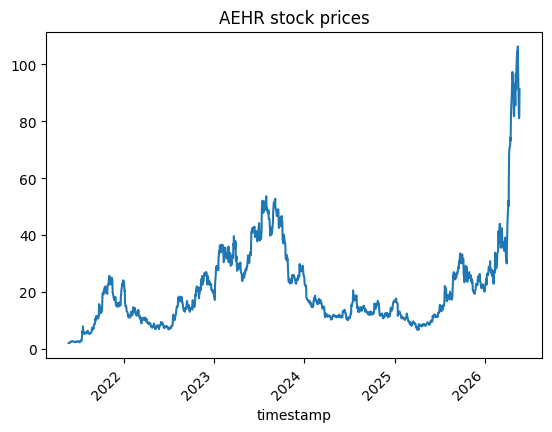

In [35]:
import matplotlib.pyplot as plt

aehr_df = df_daily_5_yr[df_daily_5_yr['ticker'] == 'AEHR']

aehr_df.set_index('timestamp')['close'].plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('AEHR stock prices')
plt.show()

# 13. Repeat the screening, but only include stocks with a market capitalization of $5 billion


In [36]:
market_cap_lim = recent_day_df[recent_day_df['market_cap'] >= 5000000000]
market_cap_lim.nlargest(10, 'pct_change_from_prev')

,timestamp,ticker,name,market_cap,close,pct_change_from_prev,close_pct_of_day1
1070426,2026-05-21,ENPH,"Enphase Energy, Inc.",7.005075e+09,62.34,17.290687,44.253567
357586,2026-05-21,AXTI,AXT Inc,6.843919e+09,121.02,15.686837,1200.595238
2688121,2026-05-21,RL,Ralph Lauren Corporation,1.993101e+10,374.90,13.868303,313.435331
2924061,2026-05-21,SPOT,Spotify Technology S.A.,8.909928e+10,489.93,13.064248,209.318124
1578701,2026-05-21,IBM,International Business Machines Corporation,2.114742e+11,252.97,12.431111,182.840449
1072936,2026-05-21,ENS,"EnerSys, Inc.",7.906831e+09,238.91,11.348807,255.819681
1869861,2026-05-21,LITE,Lumentum Holdings Inc. Common Stock,6.753585e+10,964.50,11.108551,1201.420030
2070661,2026-05-21,MP,MP Materials Corp.,1.005825e+10,61.74,9.274336,233.157100
411551,2026-05-21,BE,Bloom Energy Corporation,8.030135e+10,307.88,9.057419,1409.061785
1440651,2026-05-21,GTX,Garrett Motion Inc. Common Stock,5.746687e+09,33.22,8.208469,447.708895


In [37]:
market_cap_lim.nlargest(10, 'close_pct_of_day1')

,timestamp,ticker,name,market_cap,close,pct_change_from_prev,close_pct_of_day1
707731,2026-05-21,CLS,"Celestica, Inc.",3.983588e+10,354.77,2.392634,4101.387283
2974261,2026-05-21,STRL,"Sterling Infrastructure, Inc. Common Stock",2.307584e+10,733.77,-2.424202,3342.915718
2532501,2026-05-21,POWL,Powell Industries Inc,9.874798e+09,270.75,-0.110681,2322.698534
1214751,2026-05-21,FIX,"Comfort Systems USA, Inc.",6.461440e+10,1835.33,-0.009807,2272.010399
5019,2026-05-21,AAOI,"Applied Optoelectronics, Inc.",1.326092e+10,176.81,6.988987,2252.356688
1910021,2026-05-21,LQDA,Liquidia Corporation Common Stock,5.493089e+09,61.97,0.323782,1992.604502
2063131,2026-05-21,MOD,Modine Manufacturing Co,1.356932e+10,250.11,-2.805736,1494.086022
411551,2026-05-21,BE,Bloom Energy Corporation,8.030135e+10,307.88,9.057419,1409.061785
2258911,2026-05-21,NVDA,Nvidia Corp,5.412561e+12,219.51,-1.772050,1406.033820
3324406,2026-05-21,VRT,Vertiv Holdings Co Class A Common Stock,1.212516e+11,323.40,2.448760,1329.223181


# Here, I will later add further exploration of the aggregate metrics I've manually calculated.

Volatility - average absolute daily percentage change across the entire span?

Could also divide this by overall change. See what stocks have moved a lot just to end up back in the same place.

Find stocks prone to switching directions. Average streak length factoring both positive and negative?

# Bonus, and personal notes

In [ ]:
# # Rescaling logic (will need adaptation)

# # Start with raw columns
# rescaled_df = df_daily_five_years[['timestamp', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'vwap', 'transactions', 'pct_change_from_prev', 'next_close_pct_change']]

# # Normalize
# cols_to_exclude = ['timestamp', 'ticker']
# normalize_cols = [col for col in rescaled_df.columns if col not in cols_to_exclude]
# rescaled_df[normalize_cols] = (rescaled_df[normalize_cols] - rescaled_df[normalize_cols].min()) / (rescaled_df[normalize_cols].max() - rescaled_df[normalize_cols].min())
